## Compare the NRMSE values for the finetuned model

Start by importing necessary libraries and turning off warnings

In [1]:
import os, sys, json, itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import nbinom as nbinom
import datetime

sys.path.append( os.path.abspath(os.path.join('..')) )

from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# Opening config file
f = open('../fpaths_config.json')
paths = json.load(f)

predictions_path = paths["nn_abundance_predictions"]
metric_figures_path = paths['metric_figures_path']
misc_figures_path = paths['misc_figures_path']


In [25]:
models = ['gru_avg_temp', 'finetuned_sj_1', 'finetuned_sj_3', 'finetuned_sj_5',
              'finetuned_sj_10', 'finetuned_sj_all']

results = pd.DataFrame(np.zeros((1,3)), columns=['Model', 'R2', 'NRMSE'])

i=0
for model in models:
    subset = pd.read_csv('{}/{}_predictions.csv'.format(predictions_path,model))
    subset['Datetime'] = pd.to_datetime(subset['Datetime'])
    
    if len(subset)>0:
        avg_mols = np.mean(subset.MoLS)
        r2 = r2_score(subset.MoLS, subset['Neural Network'])
        nrmse = 1/avg_mols*np.sqrt(mean_squared_error(subset.MoLS, subset['Neural Network']))
        results.loc[i,:] = [model, r2, nrmse]
    else:
        results.loc[i,:] = [model, 0, 0]
    i+=1


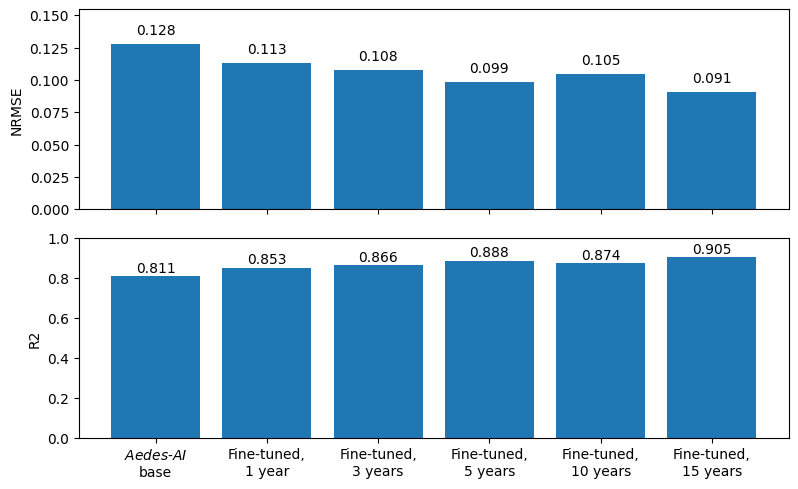

In [26]:
models = ['gru_avg_temp', 'finetuned_sj_1', 'finetuned_sj_3', 'finetuned_sj_5', 'finetuned_sj_10', 'finetuned_sj_all']

names = ['$\it{Aedes}$-$\it{AI}$\nbase', 'Fine-tuned,\n1 year', 'Fine-tuned,\n3 years',
          'Fine-tuned,\n5 years', 'Fine-tuned,\n10 years', 'Fine-tuned,\n15 years']

# Use tab10 colormap for distinct colors
colors = ['tab:blue', 'tab:orange', 'tab:orange', 'tab:orange', 'tab:orange', 'tab:orange']

metrics = ['NRMSE', 'R2']
scores = [results.NRMSE, results.R2]

fig, axs = plt.subplots(2, figsize=(8, 5), sharex=True)
for metric, score, ax in zip(metrics, scores, axs):
    bars = ax.bar(models, score, color='tab:blue')

    #Use descriptive names for xtick labels
    ax.set_xticks(models)
    ax.set_xticklabels(names, rotation=0, ha='center', fontsize=10)

    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                f'{height:.3f}', ha='center', va='bottom')

    # Add labels and title
    ax.set_ylabel(metric)
    if metric=='NRMSE':
        ax.set_ylim([0, ax.get_ylim()[-1]+0.02])
    else:
        ax.set_ylim([0, ax.get_ylim()[-1]+0.05])
    #ax.set_ylim([0, 0.32])
fig.tight_layout()

#fig.savefig('{}/nrmse_finetuning.png'.format(misc_figures_path), bbox_inches='tight', dpi=300)

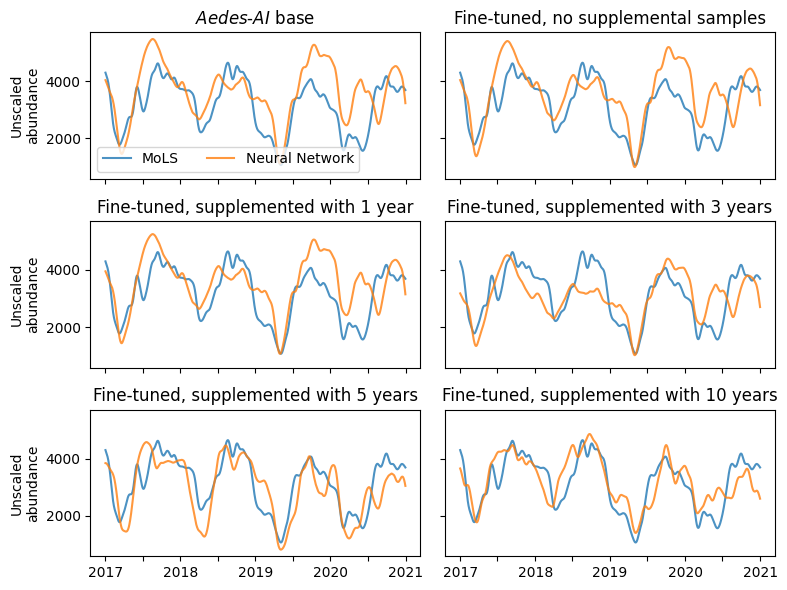

In [17]:
models = ['gru_avg_temp', 'finetuned_noise_0', 'finetuned_noise_1', 'finetuned_noise_3', 'finetuned_noise_5', 'finetuned_noise_10']
names = ['$\it{Aedes}$-$\it{AI}$ base', 'Fine-tuned, no supplemental samples', 'Fine-tuned, supplemented with 1 year',
          'Fine-tuned, supplemented with 3 years', 'Fine-tuned, supplemented with 5 years',
          'Fine-tuned, supplemented with 10 years']


fig, axs = plt.subplots(3,2, figsize=(8,6), sharex=True, sharey=True)
axs = axs.ravel()
i = 0
for model,name,ax in zip(models,names,axs):
    subset = pd.read_csv('{}/{}_predictions.csv'.format(predictions_path, model))
    subset.Datetime = pd.to_datetime(subset.Datetime)
    
    
    ax.plot(subset.Datetime, subset['MoLS'], label='MoLS', color='tab:blue', alpha=0.8)
    ax.plot(subset.Datetime, subset['Neural Network'], label='Neural Network', color='tab:orange', alpha=0.8)
    ax.set_title(name)

    # Format x-axis ticks as "mm/yyyy"
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    # Hide every other x tick label
    for j, label in enumerate(ax.get_xticklabels()):
        if j % 2 != 0:
            label.set_visible(False)
    if (i%2) == 0:
        ax.set_ylabel('Unscaled\nabundance')
    i+=1

axs[0].legend(loc='lower left', ncol=2)
fig.tight_layout()
fig.savefig('{}/finetuning_experiments.png'.format(misc_figures_path), bbox_inches='tight', dpi=300)
plt.show()
